---
title: Hexbin Plots
subtitle: DS 2023 | Communicating with Data
---

## Overview

One limitation of a scatterplot is that it doesn't do a good job of showing how many data points exists at a specific location. 

The problem is called **occlusion** because some data point representations occlude others.

## A simple example

In the case of the Penguins data set, you can see that the three clusters have more points in their centroids, but it is not clear how many points are being covered up by other points.

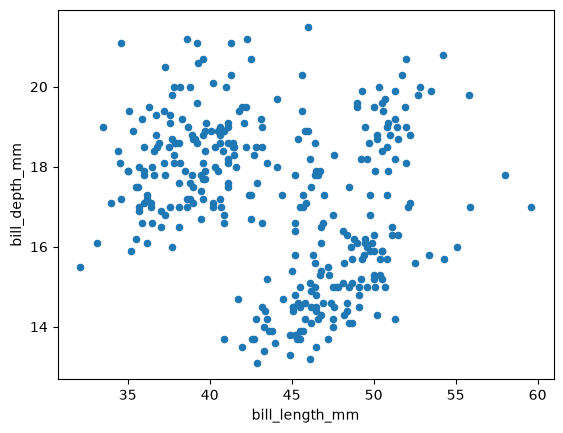

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset('penguins').dropna()

penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm')
plt.show()

One way to address the problem is to set the `alpha` parameter to a number less than $1$. 

In graphics lingo, the variable alpha $\alpha$ stands for the color opacity of a visual element.

With a low alpha, stacked points appear darker because the colors of overlapping data points add up.

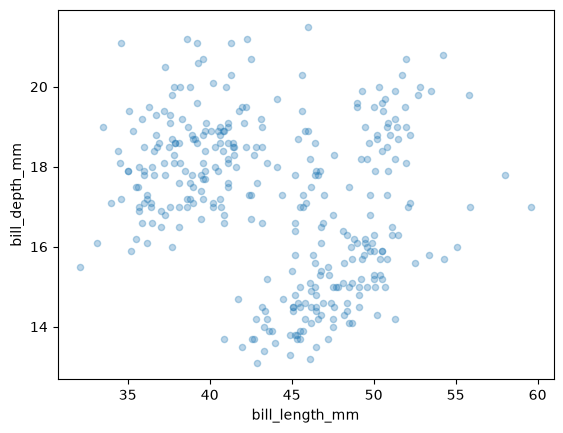

In [38]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm', alpha=.3)
plt.show()

This is good, but we can do better.

Another approach is to divide the space into cells and color each cell as a function of the number of data points in the cell.

Pandas provides a `.plot.hexbin()` method that divides the space into hexagons and shades them by the concentration of data points.

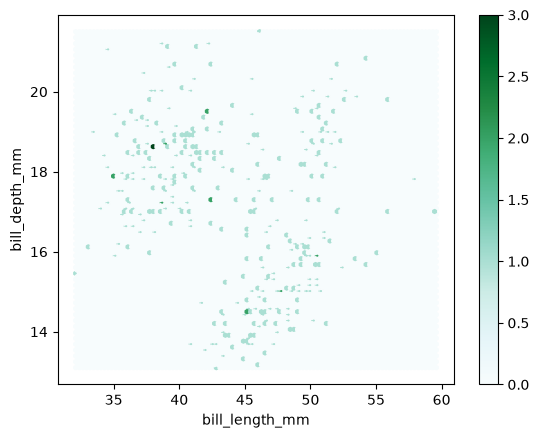

In [26]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm')
plt.show()

To get the most out of this method, it is best to choose a `gridsize` value large enough to group a significant number of points in eache cell.

Here we use a value of $25$.

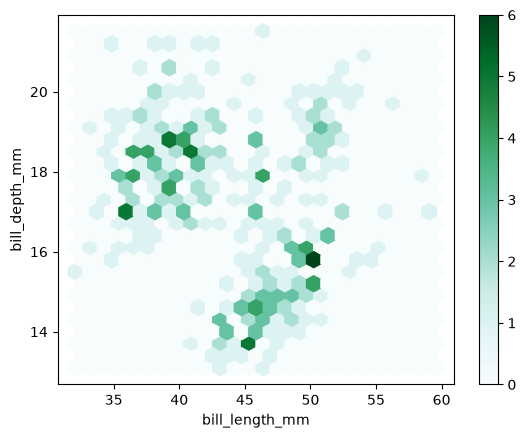

In [27]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm', gridsize=25)
plt.show()

Finally, we can choose a color map that accentuates the 

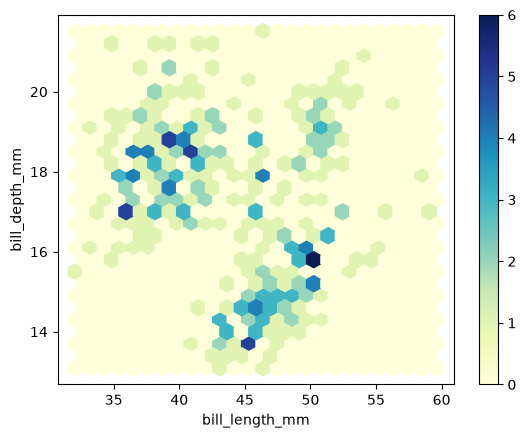

In [28]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm', gridsize=25, cmap="YlGnBu")
plt.show()

The resulting image is a kind of **heatmap**.

We'll review these in a later chapter.


## A nore complex example

Let's look at a data set with more occulusion.

The following data set for abalone in humans is from the UC Irvine Machine Learning Repository.


Abalone is a large sea snail with rich, flavorful meat. 

According to the UCI site, the data set may used for [redicting the age of abalone from physical measurements.  

> The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- a boring and time-consuming task.  Other measurements, which are easier to obtain, are used to predict the age.  Further information, such as weather patterns and location (hence food availability) may be required to solve the problem.


Conveniently, the data are avaiable through a Python page `ucimlrepo`.

In [80]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone_raw = fetch_ucirepo(id=1) 
abalone = abalone_raw.data['original']

In [81]:
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


We use a scatter matrix to find a candidate pair of features.

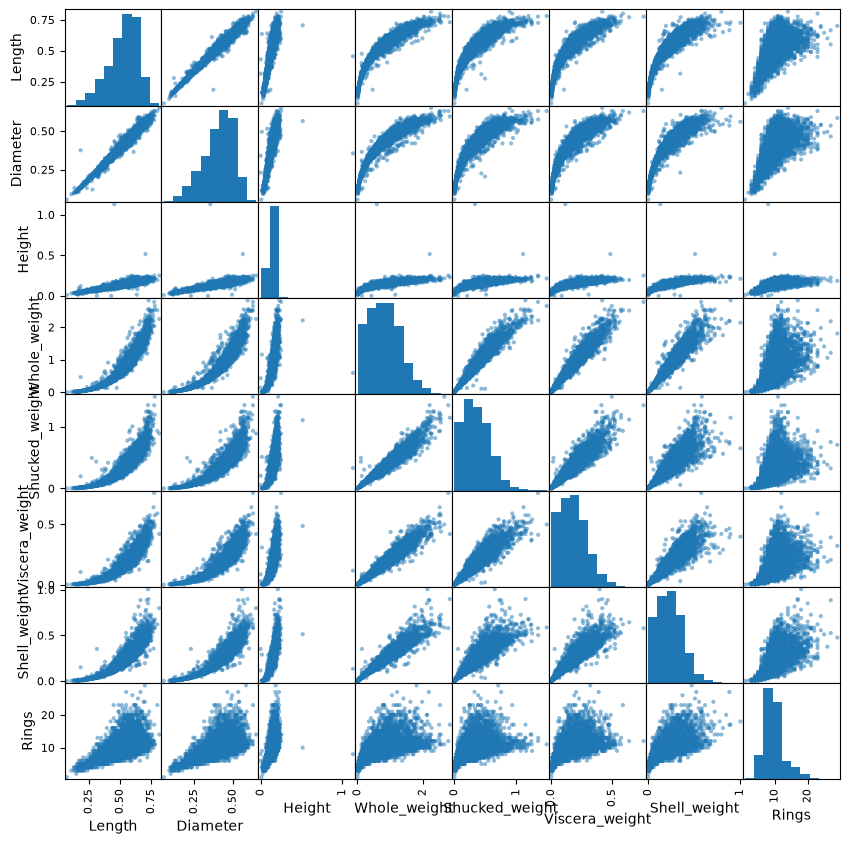

In [82]:
pd.plotting.scatter_matrix(abalone, figsize=(10,10))
plt.show()

From this, `Diameter` and `Shell_weight` look useful for demonstrating the value of a hexbin.

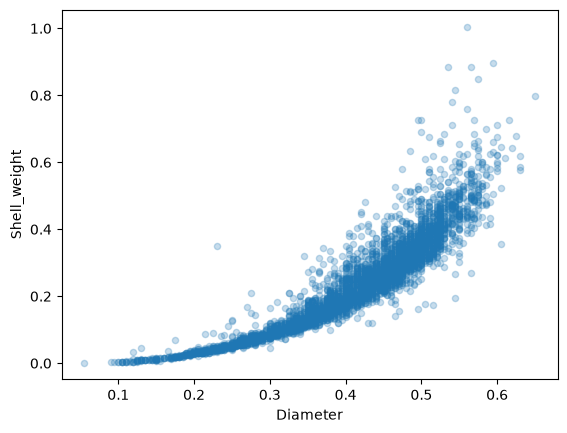

In [90]:
abalone.plot.scatter(x='Diameter', y='Shell_weight', alpha=.25)
plt.show()

Now, here is a hexbin version.

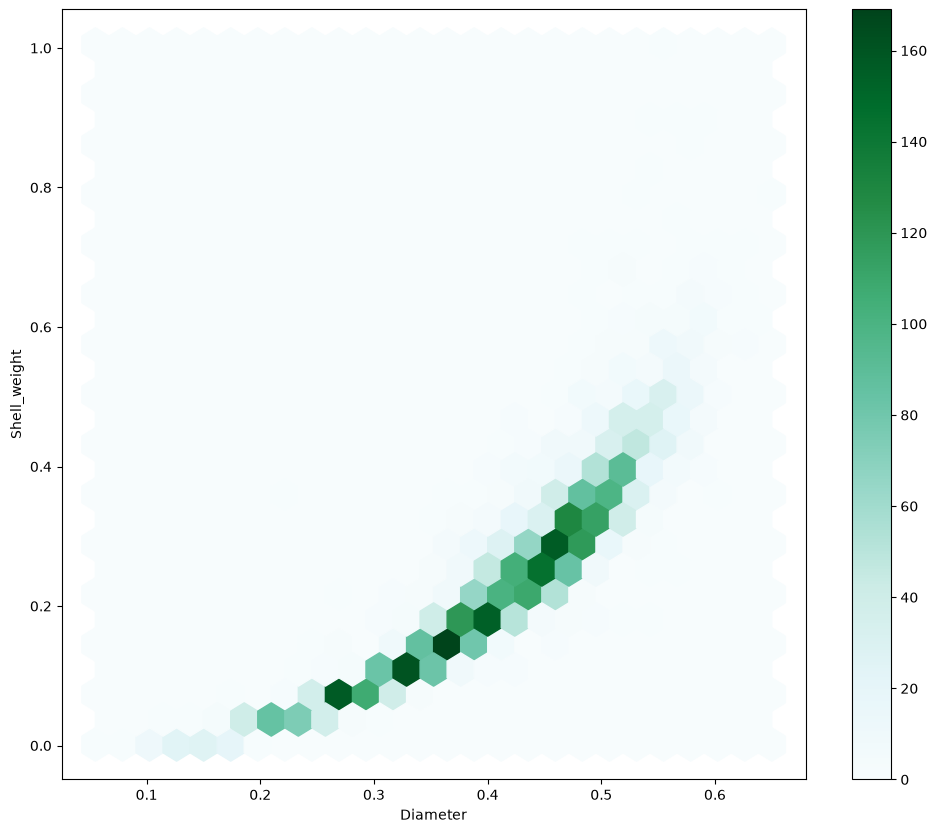

In [84]:
abalone.plot.hexbin(x='Diameter', y='Shell_weight', gridsize=25, figsize=(12,10))
plt.show()

In [ ]:
The hexbin plot gives us a much better representation of the concentration of data.

Here is another pair of features.

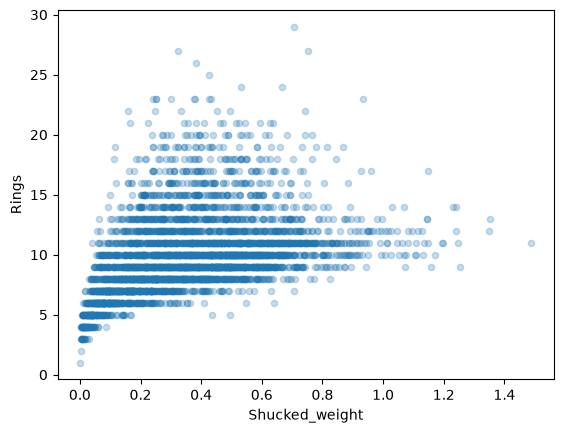

In [91]:
abalone.plot.scatter(x='Shucked_weight', y='Rings', alpha=.25)
plt.show()

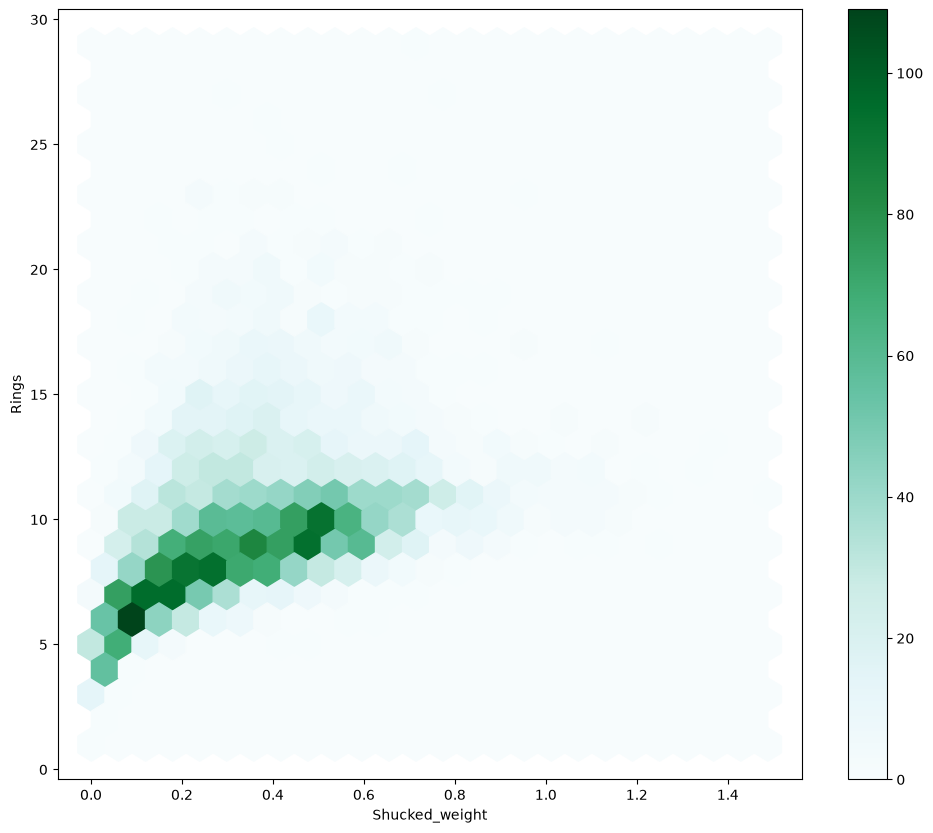

In [87]:
abalone.plot.hexbin(x='Shucked_weight', y='Rings', gridsize=25, figsize=(12,10))
plt.show()